In [3]:
 import pandas as pd
import numpy as np

In [4]:
df1=pd.read_csv('/content/sample_data/train.csv')
df2=pd.read_csv('/content/sample_data/test.csv')
df1.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
df1.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
age_mean=df1['Age'].mean()
df1['Age']=df1['Age'].fillna(age_mean)
df1.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,NaN,C


In [7]:
df1=df1.drop('Cabin',axis=1)

In [8]:
df1.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
df1.dropna(inplace=True)
df1.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [12]:
dumies=pd.get_dummies(df1[['Sex','Embarked']])
dumies.head()

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,False,True,False,False,True
1,True,False,True,False,False
2,True,False,False,False,True
3,True,False,False,False,True
4,False,True,False,False,True


In [13]:
x=df1.drop(['Survived','Name','Ticket','Sex','PassengerId'],axis=1)
x=pd.concat([x,dumies],axis=1)
x=x.drop(['Embarked','Embarked_S'],axis=1)
x

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q
0,3,22.000000,1,0,7.2500,False,True,False,False
1,1,38.000000,1,0,71.2833,True,False,True,False
2,3,26.000000,0,0,7.9250,True,False,False,False
3,1,35.000000,1,0,53.1000,True,False,False,False
4,3,35.000000,0,0,8.0500,False,True,False,False
...,...,...,...,...,...,...,...,...,...
886,2,27.000000,0,0,13.0000,False,True,False,False
887,1,19.000000,0,0,30.0000,True,False,False,False
888,3,29.699118,1,2,23.4500,True,False,False,False
889,1,26.000000,0,0,30.0000,False,True,True,False


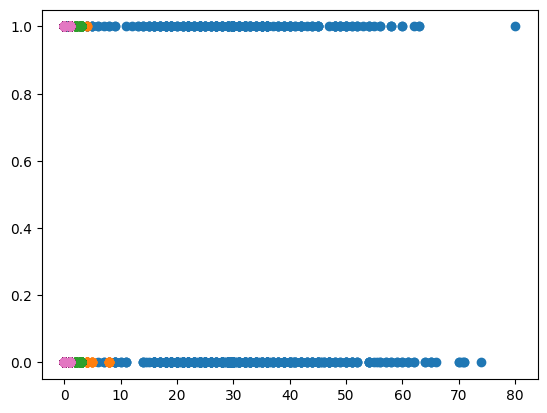

In [14]:
import matplotlib.pyplot as plt
plt.scatter(df1['Age'],df1['Survived'],label='red')
plt.scatter(df1['SibSp'],df1['Survived'],label='blue')
plt.scatter(df1['Pclass'],df1['Survived'],label='pink')
plt.scatter(dumies['Sex_female'],df1['Survived'],label='yellow')
plt.scatter(dumies['Sex_male'],df1['Survived'],label='black')
plt.scatter(dumies['Embarked_C'],df1['Survived'],label='green')
plt.scatter(dumies['Embarked_Q'],df1['Survived'],label='cyan')



In [15]:
y=df1['Survived']
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [16]:
cross_val_score(LogisticRegression(max_iter=1000),x,y,cv=5).mean()

np.float64(0.786313718021964)

In [17]:
cross_val_score(DecisionTreeClassifier(),x,y,cv=5).mean()

np.float64(0.7773186059798134)

In [18]:
cross_val_score(RandomForestClassifier(),x,y,cv=30).mean()

np.float64(0.8168199233716475)

In [19]:
cross_val_score(RandomForestClassifier(criterion='entropy'),x,y,cv=5).mean()

np.float64(0.8166825366596839)

In [20]:
cross_val_score(SVC(),x,y,cv=5).mean()

np.float64(0.6726845680187902)

In [21]:

model_params={
    'svm':{
        'model':SVC(gamma='auto'),
        'params':{
            'C':[1,10,20],
            'kernel':['rbf','linear']
        }
    },
    'random_forest':{
        'model':RandomForestClassifier(),
        'params':{
            'n_estimators':[1,5,10]
        }
    },
    'logistic_regression':{
        'model':LogisticRegression(solver='liblinear',max_iter=1000),
        'params':{
            'C':[1,5,10]
        }
    },
    'Decision_tree':{
        'model':DecisionTreeClassifier(),
        'params':{
            'criterion':['gini','entropy']
        }
    }
}

In [22]:
scores=[]
for model_name,np in model_params.items():
   clf=GridSearchCV(np['model'],np['params'],cv=5,return_train_score=False)
   clf.fit(x,y)
   scores.append({
       'model':model_name,
       'best_score':clf.best_score_,
       "best_params":clf.best_params_
   })

In [23]:
df=pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,svm,0.787399,"{'C': 1, 'kernel': 'linear'}"
1,random_forest,0.800952,{'n_estimators': 10}
2,logistic_regression,0.791938,{'C': 1}
3,Decision_tree,0.780664,{'criterion': 'entropy'}


In [24]:
import joblib

main_model=RandomForestClassifier(n_estimators=10)
main_model.fit(x,y)
main_model.score(x,y)
#joblib.dump(main_model,'main_model.pkl')

0.9640044994375703

In [25]:
df2

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [26]:
df2.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [27]:
len(df2)

418

In [28]:
df2=df2.drop('Cabin',axis=1)

In [29]:
df2.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [30]:
df2.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Embarked,0


In [31]:
age2_mean=df2['Age'].mean()
fare2_mean=df2['Fare'].mean()
df2['Fare']=df2['Fare'].fillna(fare2_mean)
df2['Age']=df2['Age'].fillna(age2_mean)
df2.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,S


In [32]:
df2.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,0


In [33]:
len(df2)

418

In [34]:
df2.dropna(inplace=True)
df2.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,0


In [35]:
len(df2)

418

In [36]:
dumies=pd.get_dummies(df2[['Sex','Embarked']])
dumies.head()

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,False,True,False,True,False
1,True,False,False,False,True
2,False,True,False,True,False
3,False,True,False,False,True
4,True,False,False,False,True


In [37]:
a=pd.concat([df2,dumies],axis=1)
a=a.drop(['Name','Ticket','Sex','Embarked','PassengerId','Embarked_S'],axis=1)
a

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q
0,3,34.50000,0,0,7.8292,False,True,False,True
1,3,47.00000,1,0,7.0000,True,False,False,False
2,2,62.00000,0,0,9.6875,False,True,False,True
3,3,27.00000,0,0,8.6625,False,True,False,False
4,3,22.00000,1,1,12.2875,True,False,False,False
...,...,...,...,...,...,...,...,...,...
413,3,30.27259,0,0,8.0500,False,True,False,False
414,1,39.00000,0,0,108.9000,True,False,True,False
415,3,38.50000,0,0,7.2500,False,True,False,False
416,3,30.27259,0,0,8.0500,False,True,False,False


In [38]:
(main_model.predict_proba(a))

array([[1.        , 0.        ],
       [0.6       , 0.4       ],
       [0.8       , 0.2       ],
       [0.3       , 0.7       ],
       [0.5       , 0.5       ],
       [0.7       , 0.3       ],
       [0.7       , 0.3       ],
       [1.        , 0.        ],
       [0.1       , 0.9       ],
       [0.8       , 0.2       ],
       [1.        , 0.        ],
       [0.9       , 0.1       ],
       [0.        , 1.        ],
       [0.8       , 0.2       ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [0.1       , 0.9       ],
       [0.8       , 0.2       ],
       [0.3       , 0.7       ],
       [0.4       , 0.6       ],
       [0.1       , 0.9       ],
       [0.        , 1.        ],
       [0.4       , 0.6       ],
       [0.2       , 0.8       ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.2       , 0.8       ],
       [0.5       , 0.5       ],
       [0.7       , 0.3       ],
       [0.

In [ ]:
probabilities = main_model.predict_proba(a)
w = [1 if prob[1] >= 0.5 else 0 for prob in probabilities]
w
df5=pd.DataFrame(w,columns=['Survived'])
df5=pd.concat([df2['PassengerId'],df5],axis=1)
df5.head()

In [ ]:
df5.to_csv('titanic_ans1.csv',index=False)

In [42]:
import pickle
pickle.dump(main_model, open("titanicK_model.pkl", "wb"))